In [1]:
import pandas as pd
import polars as pl
from matplotlib import pyplot as plt
import plotnine as pn

In [2]:
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *

mapping_table = pd.read_csv("./random_mapping.csv")

sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")


/home/a379i/Scripts/utils/load_gtf_cgc_dresden.py:106: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Extended predisp' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.


In [5]:
py_or_res_aberrant = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_predisppadjust_cnv.parquet",)
py_or_res_aberrant = py_or_res_aberrant[(py_or_res_aberrant["padjust"] <= 0.05) | ((py_or_res_aberrant["padjust_predisp_extended"].notna()) & (py_or_res_aberrant["padjust_predisp_extended"] <= 0.05))]
py_or_res_aberrant = pd.merge(py_or_res_aberrant, sa[["pid", "Diag", "seq_type", "Oncotree Code"]], left_on="sampleID", right_on="pid")
py_or_res_aberrant = py_or_res_aberrant.merge(mapping_table, left_on="sampleID", right_on="nct_id").drop(columns=["sampleID", "nct_id", "pid"])
py_or_res_aberrant.to_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/final_res/outrider_or_variants_predisppadjust_cnv.parquet")



In [6]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"

pr_res_all = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants_predisppadjust_cnv.parquet")
pr_res_all = pr_res_all[(pr_res_all["padjust"] <= 0.1) | ((pr_res_all["padjust_predisp_extended"].notna()) & (pr_res_all["padjust_predisp_extended"] <= 0.1))]
pr_res_all = pd.merge(pr_res_all, sa[["pid", "Diag", "seq_type", "Oncotree Code"]], left_on="sampleID", right_on="pid")
pr_res_all = pr_res_all.merge(mapping_table, left_on="sampleID", right_on="nct_id").drop(columns=["sampleID", "nct_id", "pid"])
pr_res_all.to_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/final_res/protrider_pr_variants_predisppadjust_cnv.parquet")


In [7]:
fr_res =  pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers_variants.tsv", sep="\t")
fr_res = pd.merge(fr_res, sa[["pid", "Diag", "seq_type", "Oncotree Code"]], left_on="sampleID", right_on="pid")
fr_res = fr_res.merge(mapping_table, left_on="sampleID", right_on="nct_id").drop(columns=["sampleID", "nct_id", "pid"])

fr_res.to_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/final_res/fraser_aggregated_outliers_variants.parquet")


In [35]:
cnv_germline = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_cnv_exploded_filtered.tsv", sep="\t")
cnv = ( pl.scan_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/cnv_exploded_filtered.tsv", separator="\t", infer_schema_length=1000000)
        .filter(pl.col("Type") != "CNN")
        .collect(engine="streaming")
      ).to_pandas()






In [41]:
cnv_sub

,seqnames,start,end,width,strand,TCN,CovRatio,BAF,c1Mean,c2Mean,Type,LOH,Gene,random_id
0,12,15718482,15807228,88747,*,6.220009,2.258226,NaN,NaN,NaN,AMP,False,EPS8,MDP1133
1,18,48591820,48917986,326167,*,0.116111,0.446889,NaN,NaN,NaN,HDEL,False,RN7SL695P,MDP1133
2,18,48591820,48917986,326167,*,0.116111,0.446889,NaN,NaN,NaN,HDEL,False,SRSF10P1,MDP1133
3,18,48591820,48917986,326167,*,0.116111,0.446889,NaN,NaN,NaN,HDEL,False,MEX3C,MDP1133
4,18,48591820,48917986,326167,*,0.116111,0.446889,NaN,NaN,NaN,HDEL,False,RNU1-46P,MDP1133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933439,Y,24381338,24508205,126868,*,0.029109,0.097300,NaN,NaN,NaN,HDEL,False,TTTY5,GTJ2968
1933440,Y,24381338,24508205,126868,*,0.029109,0.097300,NaN,NaN,NaN,HDEL,False,TSPY22P,GTJ2968
1933441,Y,24381338,24508205,126868,*,0.029109,0.097300,NaN,NaN,NaN,HDEL,False,RBMY1J,GTJ2968
1933442,Y,24381338,24508205,126868,*,0.029109,0.097300,NaN,NaN,NaN,HDEL,False,RBMY2FP,GTJ2968


In [40]:
cnv_sub = cnv[((cnv["Type"] == "AMP") | (cnv["Type"] == "HDEL")) & (cnv["width"] >= 10000)]
cnv_sub = cnv_sub.merge(mapping_table, left_on="sampleID", right_on="nct_id").drop(columns=["sampleID", "nct_id", "group", "group_name", "key"])
cnv_sub.to_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/final_res/cnv_AMP_HDEL.parquet", index=None)



In [9]:
cnv_germline = cnv_germline[(cnv_germline["Confidence"] == "HIGH") & (cnv_germline["width"] >= 10000)]
cnv_germline = cnv_germline.merge(mapping_table, left_on="sampleID", right_on="nct_id").drop(columns=["sampleID", "nct_id", "group", "group_name", "key"])
cnv_germline.to_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/final_res/cnv_germline_high_confidence.parquet", index=None)


## 

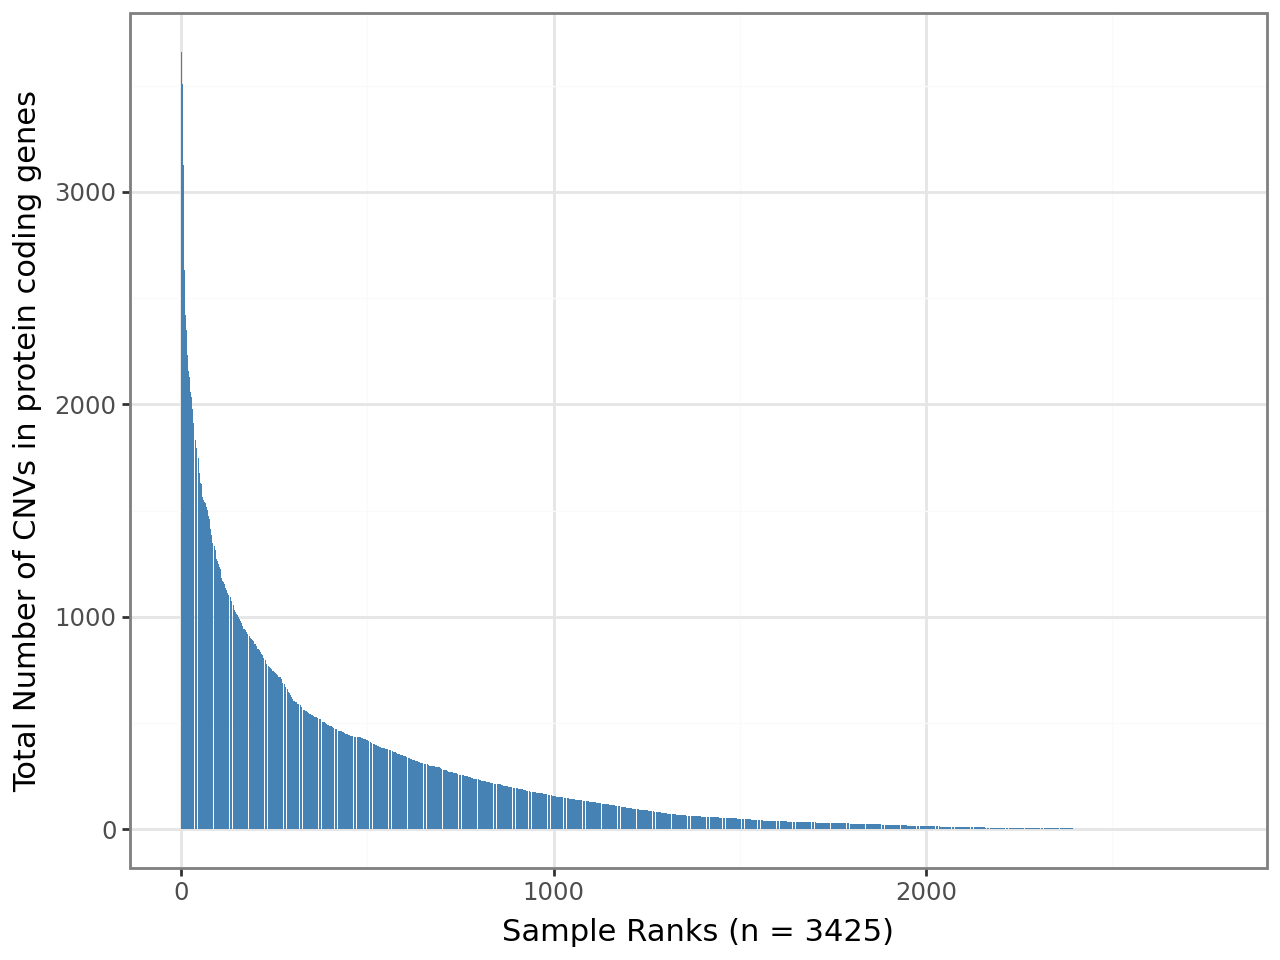

In [30]:
sample_counts = cnv_sub[cnv_sub["Gene"].isin(gene_annot_dt[gene_annot_dt["gene_type"] == "protein_coding"]["gene_name"])].groupby('group_name').size().reset_index(name='total_cnvs')

# 3. Sort samples by total CNVs (optional but recommended for readability)
sample_counts = sample_counts.sort_values('total_cnvs', ascending=False)
sample_counts['sample'] = pd.Categorical(sample_counts['group_name'], 
                                         categories=sample_counts['group_name'], 
                                         ordered=True)
sample_counts['sample'] = (
    sample_counts['sample']
    .astype(str)
    .pipe(lambda x: pd.Categorical(x, categories=sample_counts.sort_values('total_cnvs', ascending=False)['sample'], ordered=True))
)
sample_counts["Rank"] = [i + 1 for i in range(len(sample_counts))]

# 4. Plot
plot = (
    pn.ggplot(sample_counts, pn.aes(x='Rank', y='total_cnvs'))
    # pn.ggplot(sample_counts, pn.aes(x='total_cnvs'))
    + pn.geom_col(fill="steelblue")
    + pn.labs(
        x=f"Sample Ranks (n = {len(cnv["group_name"].unique())})",
        y="Total Number of CNVs in protein coding genes"
    )
    # + pn.scale_y_log10()
    + pn.theme_bw()
    # + pn.theme(
    #     axis_text_x=pn.element_blank() # Rotates sample names so they don't overlap
    # )
)
plot


In [29]:
cnv_sub[cnv_sub["Gene"].isin(gene_annot_dt[gene_annot_dt["gene_type"] == "protein_coding"]["gene_name"])].shape[0] / 3425


192.06335766423356

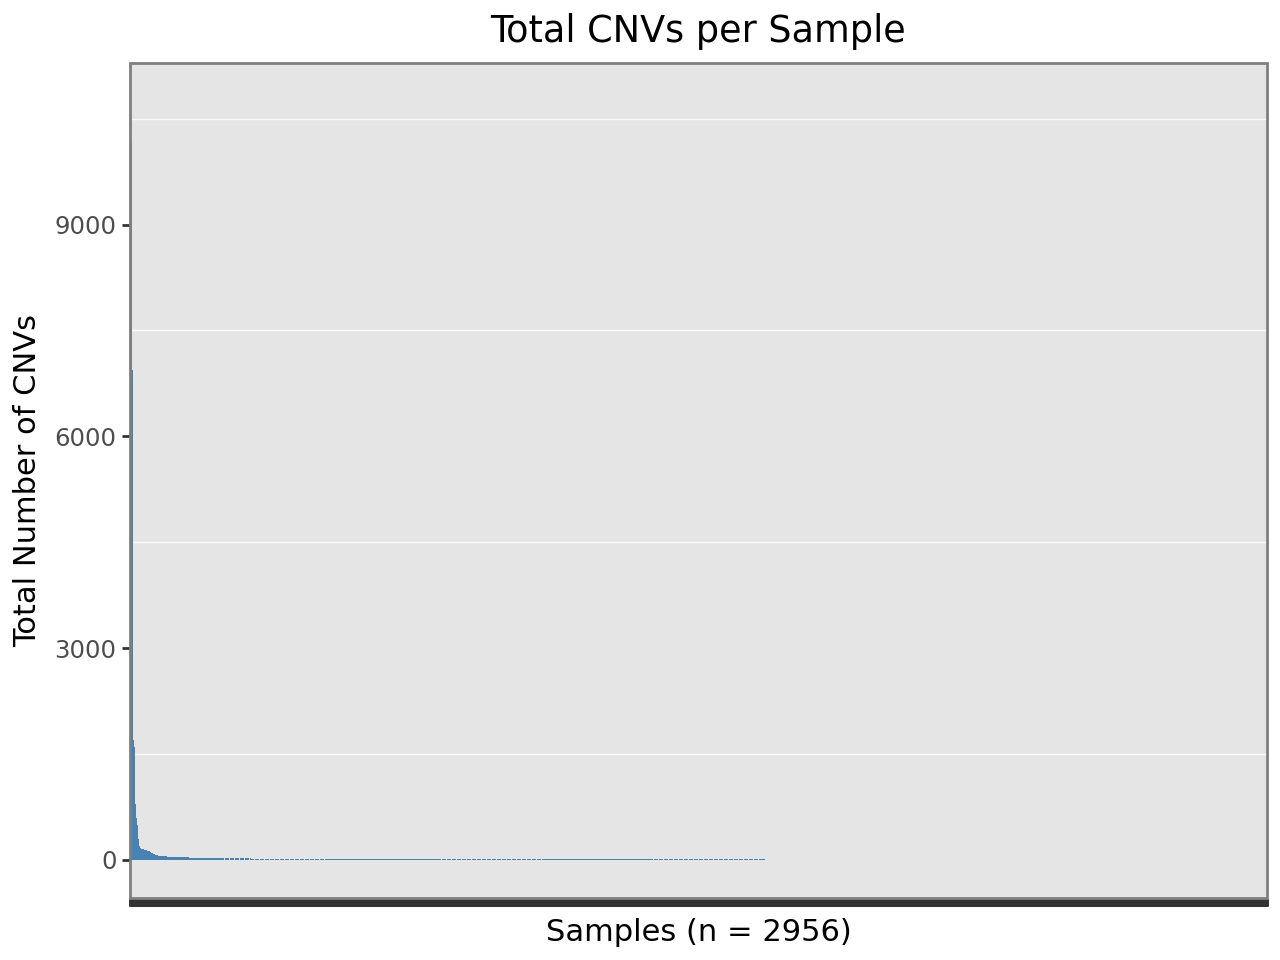

In [62]:
sample_counts = cnv_germline.groupby('random_id').size().reset_index(name='total_cnvs')

# 3. Sort samples by total CNVs (optional but recommended for readability)
sample_counts = sample_counts.sort_values('total_cnvs', ascending=False)
sample_counts['sample'] = pd.Categorical(sample_counts['random_id'], 
                                         categories=sample_counts['random_id'], 
                                         ordered=True)

# 4. Plot
plot = (
    pn.ggplot(sample_counts, pn.aes(x='sample', y='total_cnvs'))
    + pn.geom_col(fill="steelblue")
    + pn.labs(
        title="Total CNVs per Sample",
        x=f"Samples (n = {len(cnv_germline["random_id"].unique())})",
        y="Total Number of CNVs"
    )
    + pn.theme_bw()
    + pn.theme(
        axis_text_x=pn.element_blank() # Rotates sample names so they don't overlap
    )
)
plot